# Titanic EDA — Who Survived, and Why?

This notebook is a self-contained exploratory data analysis (EDA) of the classic Titanic
passenger dataset. No modeling here — the goal is to understand the shape of the data,
clean it responsibly, and answer one question with evidence: **who survived, and why?**

**How to run:** `Kernel → Restart & Run All`. The only input is `data/titanic.csv`,
loaded via a path relative to the repo root, so this works on any machine that clones the repo.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)


## 2. Load data

Single cell, relative path from the repo root — no absolute paths, no re-downloading.

In [2]:
DATA_PATH = "../data/titanic.csv"  # relative to notebooks/, i.e. <repo_root>/data/titanic.csv
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")
df.head()


Loaded 891 rows and 12 columns


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

## 3. First look at the data

Before cleaning anything, check dtypes and missingness so every cleaning decision below
is justified by what's actually in the data, not by habit.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


          missing_count  missing_pct
Cabin               687         77.1
Age                 177         19.9
Embarked              2          0.2

## 4. Cleaning

Three columns have missing values: `Cabin` (77% missing), `Age` (~20% missing), and
`Embarked` (2 rows). Each decision below is made independently and explained inline.


In [5]:
df_clean = df.copy()

# --- Age: ~20% missing, but Age is central to the survival story ("women and children
# first"), so we can't just drop these rows without losing a fifth of the data and
# biasing the sample. Median imputation is a reasonable, low-distortion default here
# because Age is right-skewed (a few elderly passengers), so the median is more
# representative than the mean.
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# --- Embarked: only 2 missing values out of 891. At this scale, imputing with the
# overwhelming majority class (mode) has virtually no effect on downstream analysis,
# and dropping 2 rows isn't worth the (tiny) complexity either way. Mode chosen for
# simplicity and because it's the safer of two near-equivalent options.
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# --- Cabin: 77% missing. This isn't "missing data" in the usual sense — it's missing
# because 3rd class tickets typically didn't include a recorded cabin. Imputing a cabin
# number would invent information that doesn't exist. Instead we extract the one honest
# signal available: whether a cabin was recorded at all. That flag turns out to matter
# because having a recorded cabin correlates strongly with deck location and class.
df_clean["HasCabin"] = df_clean["Cabin"].notna().astype(int)
df_clean = df_clean.drop(columns=["Cabin"])

# --- Feature engineering: family size and being alone are known from domain knowledge
# (and the original Kaggle discussion of this dataset) to affect survival more than
# SibSp or Parch do individually, since they capture the same "who was traveling
# together" signal in one number.
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

# --- Age groups: bucketing makes the "women and children first" pattern visible in a
# bar chart in a way that a continuous Age column would not.
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"], bins=[0, 12, 18, 35, 60, 100],
    labels=["Child (0-12)", "Teen (13-18)", "Adult (19-35)", "Middle age (36-60)", "Senior (60+)"]
)

# --- Columns dropped entirely: PassengerId (row identifier, no signal), Name and
# Ticket (free text/IDs with no direct analytical value at the EDA stage; titles could
# be extracted from Name but that's a modeling-stage feature, out of scope for pure EDA).
df_clean = df_clean.drop(columns=["PassengerId", "Name", "Ticket"])

print("Missing values remaining:")
print(df_clean.isna().sum().sum())
df_clean.head()


Missing values remaining:
0


   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  HasCabin  \
0         0       3    male  22.0      1      0   7.2500        S         0   
1         1       1  female  38.0      1      0  71.2833        C         1   
2         1       3  female  26.0      0      0   7.9250        S         0   
3         1       1  female  35.0      1      0  53.1000        S         1   
4         0       3    male  35.0      0      0   8.0500        S         0   

   FamilySize  IsAlone            AgeGroup  
0           2        0       Adult (19-35)  
1           2        0  Middle age (36-60)  
2           1        1       Adult (19-35)  
3           2        0       Adult (19-35)  
4           1        1       Adult (19-35)  

## 5. Exploring survival

Three views, chosen to build one story rather than to show every possible chart.

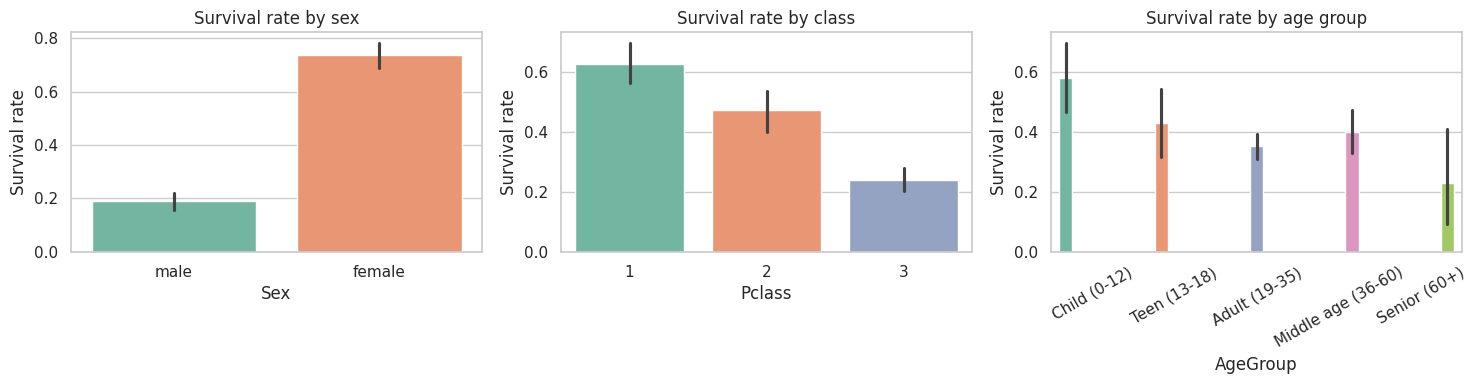

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=df_clean, x="Sex", y="Survived", hue="Sex", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Survival rate by sex")
axes[0].set_ylabel("Survival rate")

sns.barplot(data=df_clean, x="Pclass", y="Survived", hue="Pclass", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Survival rate by class")
axes[1].set_ylabel("Survival rate")

sns.barplot(data=df_clean, x="AgeGroup", y="Survived", hue="AgeGroup", legend=False, ax=axes[2], palette="Set2")
axes[2].set_title("Survival rate by age group")
axes[2].set_ylabel("Survival rate")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Sex and class each show a strong, independent effect. The next chart checks whether
they combine — i.e. whether class still matters once we already know someone's sex.

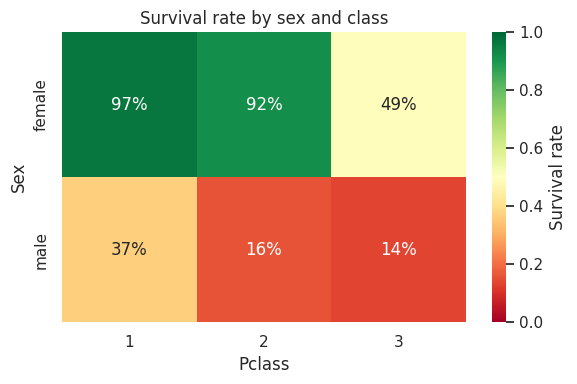

In [7]:
pivot = df_clean.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Survival rate"})
ax.set_title("Survival rate by sex and class")
plt.tight_layout()
plt.show()


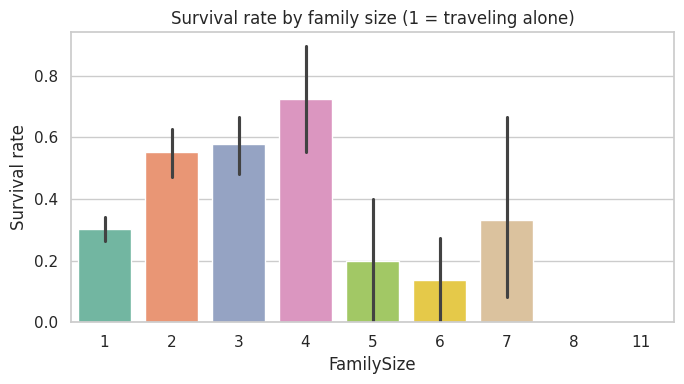

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df_clean, x="FamilySize", y="Survived", hue="FamilySize", legend=False, ax=ax, palette="Set2")
ax.set_title("Survival rate by family size (1 = traveling alone)")
ax.set_ylabel("Survival rate")
plt.tight_layout()
plt.show()


## 6. Findings (~150 words)

Survival on the Titanic was overwhelmingly shaped by **sex** and **class**, and the two
compounded each other. Women survived at about 74%, versus 19% for men — consistent with
a "women and children first" evacuation norm. First-class passengers survived at 63%
versus 24% in third class, reflecting both cabin proximity to lifeboats and possible
boarding priority. The two factors stack: first-class women survived at 97%, while
third-class men survived at just 14% — a 7x gap driven almost entirely by who you were,
not how you behaved. Age mattered at the margins: children had a noticeably higher
survival rate than adults, in line with the same evacuation norm. Family size shows a
mild curve — small families (2-4 people) survived more often than solo travelers or very
large families, who may have struggled to stay together or find space.

## 7. What I'd do next with more time

- Extract titles from `Name` (Mr/Mrs/Miss/Master) as a proxy for age and social status where Age is imputed
- Look at `Fare` and ticket-sharing to approximate group bookings more precisely than `FamilySize` alone
- Check whether `Embarked` port correlates with class/fare in a way that confounds the survival story
- Move to a simple baseline model (logistic regression) to quantify each factor's effect while holding others constant
